In [1]:
# ============================================================
# NOTEBOOK 01: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# Proyecto: Credit Risk Scoring ML
# Autor: Marín Serrato Barrios
# Descripción: Exploración inicial del dataset Home Credit
#              Default Risk para entender la estructura,
#              calidad y distribución de los datos
# ============================================================

# --- IMPORTACIÓN DE LIBRERÍAS ---

import pandas as pd          # Manipulación de datos
import numpy as np           # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas básicas
import seaborn as sns        # Gráficas estadísticas

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8')  # Estilo visual de las gráficas
sns.set_palette('husl')         # Paleta de colores

# Configuración de pandas
pd.set_option('display.max_columns', 100)  # Ver hasta 100 columnas
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimales

print("✅ Librerías importadas correctamente")
print(f"   pandas:     {pd.__version__}")
print(f"   numpy:      {np.__version__}")
print(f"   matplotlib: {plt.matplotlib.__version__}")
print(f"   seaborn:    {sns.__version__}")

✅ Librerías importadas correctamente
   pandas:     3.0.2
   numpy:      2.4.4
   matplotlib: 3.10.8
   seaborn:    0.13.2


In [14]:
# --- CONFIGURAR RUTA BASE DEL PROYECTO ---

import os

# Obtener la ruta absoluta de la raíz del proyecto
# __file__ no funciona en notebooks, usamos os.getcwd()
# y subimos un nivel desde la carpeta notebooks/

ruta_base = os.path.dirname(os.getcwd())

# Verificar que estamos en el lugar correcto
print(f"Ruta base del proyecto: {ruta_base}")

# Cambiar el directorio de trabajo a la raíz del proyecto
os.chdir(ruta_base)
print(f"Directorio de trabajo actual: {os.getcwd()}")

# Verificar que la carpeta reports existe
print(f"Carpeta reports existe: {os.path.exists('reports')}")

Ruta base del proyecto: c:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml
Directorio de trabajo actual: c:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml
Carpeta reports existe: True


In [2]:
# --- CARGA DEL DATASET ---

# El dataset de Home Credit viene en un archivo ZIP
# que contiene varios archivos CSV.
# El archivo principal es application_train.csv
# que contiene las solicitudes de crédito con su target.

import zipfile  # Librería estándar de Python para manejar archivos ZIP
import os       # Para manejar rutas y archivos del sistema

# Ruta al archivo ZIP descargado de Kaggle
ruta_zip = "C:/Users/Marin/Documents/PROYECTO ML_OPS/credit-risk-scoring-ml/data/raw/home-credit-default-risk.zip"

# Ver qué archivos contiene el ZIP sin descomprimirlo
with zipfile.ZipFile(ruta_zip, 'r') as z:
    archivos = z.namelist()
    
print("Archivos dentro del ZIP:")
for archivo in sorted(archivos):
    print(f"  {archivo}")

Archivos dentro del ZIP:
  HomeCredit_columns_description.csv
  POS_CASH_balance.csv
  application_test.csv
  application_train.csv
  bureau.csv
  bureau_balance.csv
  credit_card_balance.csv
  installments_payments.csv
  previous_application.csv
  sample_submission.csv


In [3]:
# --- CARGA DEL ARCHIVO PRINCIPAL ---

# Leemos application_train.csv directamente desde el ZIP
# sin necesidad de descomprimirlo primero
# Esto ahorra espacio en disco

with zipfile.ZipFile(ruta_zip, 'r') as z:
    # Abrir el archivo CSV dentro del ZIP
    with z.open('application_train.csv') as f:
        df = pd.read_csv(f)

# Confirmar que cargó correctamente
print(f"Dataset cargado exitosamente")
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

Dataset cargado exitosamente
Filas:    307,511
Columnas: 122


In [4]:
# --- ESTRUCTURA DEL DATASET ---

# Primero veamos las primeras 5 filas
# para entender cómo se ven los datos
print("PRIMERAS 5 FILAS:")
print("="*60)
df.head()

PRIMERAS 5 FILAS:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,

In [5]:
# --- TIPOS DE DATOS Y VALORES NULOS ---

# .info() es uno de los comandos más útiles en pandas
# Muestra de un vistazo:
#   - Nombre de cada columna
#   - Cuántos valores NO nulos tiene
#   - Tipo de dato (int, float, object)
#   - Memoria que ocupa el dataset

print("INFORMACIÓN GENERAL DEL DATASET:")
print("="*60)
df.info(verbose=True, show_counts=True)

INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  str    
 3    CODE_GENDER                   307511 non-null  str    
 4    FLAG_OWN_CAR                  307511 non-null  str    
 5    FLAG_OWN_REALTY               307511 non-null  str    
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  str    
 12   NAME_I

In [6]:
# --- ANÁLISIS DEL TARGET ---
# El TARGET es nuestra variable objetivo:
#   0 = el cliente pagó correctamente (BUENO)
#   1 = el cliente no pagó (MALO, entró en mora)

print("DISTRIBUCIÓN DEL TARGET:")
print("="*60)

# Conteo absoluto
conteo = df['TARGET'].value_counts()
print(f"\nConteo absoluto:")
print(f"  Pagó bien  (0): {conteo[0]:>10,}")
print(f"  No pagó    (1): {conteo[1]:>10,}")

# Porcentaje
porcentaje = df['TARGET'].value_counts(normalize=True) * 100
print(f"\nDistribución porcentual:")
print(f"  Pagó bien  (0): {porcentaje[0]:>9.2f}%")
print(f"  No pagó    (1): {porcentaje[1]:>9.2f}%")

# Ratio de desbalance
ratio = conteo[0] / conteo[1]
print(f"\nRatio de desbalance: {ratio:.1f}:1")
print(f"(Por cada cliente malo hay {ratio:.1f} clientes buenos)")

DISTRIBUCIÓN DEL TARGET:

Conteo absoluto:
  Pagó bien  (0):    282,686
  No pagó    (1):     24,825

Distribución porcentual:
  Pagó bien  (0):     91.93%
  No pagó    (1):      8.07%

Ratio de desbalance: 11.4:1
(Por cada cliente malo hay 11.4 clientes buenos)


FileNotFoundError: [Errno 2] No such file or directory: 'reports/01_distribucion_target.png'

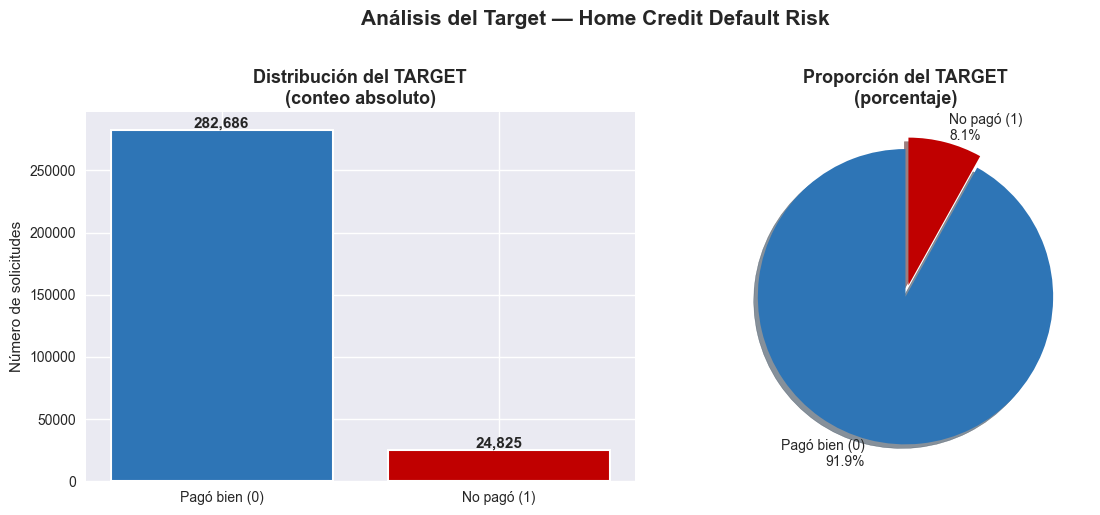

In [7]:
# --- GRÁFICA DE DISTRIBUCIÓN DEL TARGET ---

# Creamos una figura con dos gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colores para buenos y malos
colores = ['#2E75B6', '#C00000']  # Azul para buenos, rojo para malos
etiquetas = ['Pagó bien (0)', 'No pagó (1)']

# GRÁFICA 1: Barras con conteo absoluto
conteo = df['TARGET'].value_counts()
axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución del TARGET\n(conteo absoluto)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de solicitudes')

# Agregar etiquetas encima de cada barra
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# GRÁFICA 2: Pie chart con porcentajes
porcentaje = df['TARGET'].value_counts(normalize=True) * 100
axes[1].pie(
    porcentaje.values,
    labels=[f'{e}\n{p:.1f}%' for e, p in zip(etiquetas, porcentaje.values)],
    colors=colores,
    startangle=90,
    explode=(0, 0.08),   # Separar ligeramente el slice de "No pagó"
    shadow=True
)
axes[1].set_title('Proporción del TARGET\n(porcentaje)', fontsize=13, fontweight='bold')

# Título general
fig.suptitle('Análisis del Target — Home Credit Default Risk',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()

# Guardar la gráfica en reports/
plt.savefig('reports/01_distribucion_target.png', dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/01_distribucion_target.png")

plt.show()

In [8]:
# --- DICCIONARIO DE DATOS ---

# HomeCredit_columns_description.csv contiene
# la descripción de cada variable del dataset
# Es el "manual" de las 122 columnas

with zipfile.ZipFile(ruta_zip, 'r') as z:
    with z.open('HomeCredit_columns_description.csv') as f:
        diccionario = pd.read_csv(f, encoding='latin-1')
        # encoding='latin-1' porque el archivo tiene
        # caracteres especiales en las descripciones

print(f"Columnas del diccionario: {diccionario.columns.tolist()}")
print(f"Total de variables descritas: {len(diccionario)}")
print()
print(diccionario.head(10))

Columnas del diccionario: ['Unnamed: 0', 'Table', 'Row', 'Description', 'Special']
Total de variables descritas: 219

   Unnamed: 0                         Table                 Row  \
0           1  application_{train|test}.csv          SK_ID_CURR   
1           2  application_{train|test}.csv              TARGET   
2           5  application_{train|test}.csv  NAME_CONTRACT_TYPE   
3           6  application_{train|test}.csv         CODE_GENDER   
4           7  application_{train|test}.csv        FLAG_OWN_CAR   
5           8  application_{train|test}.csv     FLAG_OWN_REALTY   
6           9  application_{train|test}.csv        CNT_CHILDREN   
7          10  application_{train|test}.csv    AMT_INCOME_TOTAL   
8          11  application_{train|test}.csv          AMT_CREDIT   
9          12  application_{train|test}.csv         AMT_ANNUITY   

                                         Description Special  
0                           ID of loan in our sample     NaN  
1  Target variable

In [9]:
# --- VARIABLES DE application_train.csv ÚNICAMENTE ---

# Filtrar solo las variables de nuestro archivo principal
vars_principales = diccionario[
    diccionario['Table'] == 'application_{train|test}.csv'
].copy()

# Limpiar el índice
vars_principales = vars_principales.reset_index(drop=True)

print(f"Variables en application_train.csv: {len(vars_principales)}")
print()

# Ver todas las variables con su descripción
pd.set_option('display.max_colwidth', 80)  # Ver descripciones completas
print(vars_principales[['Row', 'Description']].to_string(index=False))

Variables en application_train.csv: 122

                         Row                                                                                                                                                                                                                                                                          Description
                  SK_ID_CURR                                                                                                                                                                                                                                                             ID of loan in our sample
                      TARGET                                                                                          Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)
          NAME_CONTRACT_TYPE             

In [10]:
# --- AGRUPACIÓN CONCEPTUAL DE VARIABLES ---

# Definimos grupos temáticos manualmente
# basados en el conocimiento del dominio crediticio

grupos = {

    'IDENTIFICADOR': [
        'SK_ID_CURR'
    ],

    'TARGET (Variable Objetivo)': [
        'TARGET'
    ],

    'DATOS DEL CRÉDITO SOLICITADO': [
        'NAME_CONTRACT_TYPE',   # Tipo: efectivo o revolvente
        'AMT_CREDIT',           # Monto del crédito
        'AMT_ANNUITY',          # Pago mensual (anualidad)
        'AMT_GOODS_PRICE',      # Precio del bien financiado
    ],

    'PERFIL SOCIODEMOGRÁFICO': [
        'CODE_GENDER',          # Género
        'DAYS_BIRTH',           # Edad (en días negativos desde hoy)
        'CNT_CHILDREN',         # Número de hijos
        'NAME_FAMILY_STATUS',   # Estado civil
        'CNT_FAM_MEMBERS',      # Miembros del hogar
        'NAME_HOUSING_TYPE',    # Tipo de vivienda
        'FLAG_OWN_CAR',         # Tiene auto
        'FLAG_OWN_REALTY',      # Tiene propiedad
        'REGION_POPULATION_RELATIVE',  # Densidad poblacional región
        'REGION_RATING_CLIENT',        # Rating de la región (1,2,3)
        'REGION_RATING_CLIENT_W_CITY', # Rating región con ciudad
    ],

    'PERFIL LABORAL E INGRESOS': [
        'NAME_INCOME_TYPE',     # Tipo de ingreso (empleado, pensionado, etc.)
        'AMT_INCOME_TOTAL',     # Ingreso anual declarado
        'NAME_EDUCATION_TYPE',  # Nivel educativo
        'OCCUPATION_TYPE',      # Ocupación
        'ORGANIZATION_TYPE',    # Tipo de organización donde trabaja
        'DAYS_EMPLOYED',        # Antigüedad laboral (días negativos)
        'DAYS_REGISTRATION',    # Días desde que registró el documento
        'DAYS_ID_PUBLISH',      # Días desde que publicó su ID
    ],

    'ACOMPAÑANTE EN LA SOLICITUD': [
        'NAME_TYPE_SUITE',      # Quién acompañó al solicitante
    ],

    'CONSULTAS AL BURÓ DE CRÉDITO': [
        'AMT_REQ_CREDIT_BUREAU_HOUR',  # Consultas última hora
        'AMT_REQ_CREDIT_BUREAU_DAY',   # Consultas último día
        'AMT_REQ_CREDIT_BUREAU_WEEK',  # Consultas última semana
        'AMT_REQ_CREDIT_BUREAU_MON',   # Consultas último mes
        'AMT_REQ_CREDIT_BUREAU_QRT',   # Consultas último trimestre
        'AMT_REQ_CREDIT_BUREAU_YEAR',  # Consultas último año
    ],

    'DOCUMENTOS Y VERIFICACIONES': [
        'FLAG_DOCUMENT_2',   # Documento 2 proporcionado
        'FLAG_DOCUMENT_3',   # Documento 3 proporcionado
        'FLAG_DOCUMENT_4',   # ... y así hasta el 21
        'FLAG_DOCUMENT_5',
        'FLAG_DOCUMENT_6',
        'FLAG_DOCUMENT_7',
        'FLAG_DOCUMENT_8',
        'FLAG_DOCUMENT_9',
        'FLAG_DOCUMENT_10',
        'FLAG_DOCUMENT_11',
        'FLAG_DOCUMENT_12',
        'FLAG_DOCUMENT_13',
        'FLAG_DOCUMENT_14',
        'FLAG_DOCUMENT_15',
        'FLAG_DOCUMENT_16',
        'FLAG_DOCUMENT_17',
        'FLAG_DOCUMENT_18',
        'FLAG_DOCUMENT_19',
        'FLAG_DOCUMENT_20',
        'FLAG_DOCUMENT_21',
        'FLAG_EMAIL',        # Tiene email registrado
        'FLAG_PHONE',        # Tiene teléfono
        'FLAG_WORK_PHONE',   # Tiene teléfono de trabajo
        'FLAG_CONT_MOBILE',  # Teléfono móvil accesible
        'FLAG_MOBIL',        # Tiene móvil
        'FLAG_EMP_PHONE',    # Tiene teléfono de empleador
    ],

    'SCORES EXTERNOS (equivalente a Buró)': [
        'EXT_SOURCE_1',  # Score externo fuente 1
        'EXT_SOURCE_2',  # Score externo fuente 2
        'EXT_SOURCE_3',  # Score externo fuente 3
    ],

    'INFORMACIÓN GEOGRÁFICA': [
        'REGION_POPULATION_RELATIVE',
        'REG_REGION_NOT_LIVE_REGION',   # Registro ≠ residencia
        'REG_REGION_NOT_WORK_REGION',   # Registro ≠ trabajo
        'LIVE_REGION_NOT_WORK_REGION',  # Residencia ≠ trabajo
        'REG_CITY_NOT_LIVE_CITY',       # Ciudad registro ≠ residencia
        'REG_CITY_NOT_WORK_CITY',       # Ciudad registro ≠ trabajo
        'LIVE_CITY_NOT_WORK_CITY',      # Ciudad residencia ≠ trabajo
    ],

    'CARACTERÍSTICAS DEL EDIFICIO / VIVIENDA': [
        'APARTMENTS_AVG',
        'BASEMENTAREA_AVG',
        'YEARS_BEGINEXPLUATATION_AVG',
        'YEARS_BUILD_AVG',
        'COMMONAREA_AVG',
        'ELEVATORS_AVG',
        'ENTRANCES_AVG',
        'FLOORSMAX_AVG',
        'FLOORSMIN_AVG',
        'LANDAREA_AVG',
        'LIVINGAPARTMENTS_AVG',
        'LIVINGAREA_AVG',
        'NONLIVINGAPARTMENTS_AVG',
        'NONLIVINGAREA_AVG',
        # ... mismas variables con sufijos _MODE y _MEDI
    ],
}

# Mostrar resumen por grupo
print("GRUPOS CONCEPTUALES DE VARIABLES")
print("="*60)
for grupo, variables in grupos.items():
    print(f"\n{grupo} ({len(variables)} variables)")
    print("-"*40)
    for v in variables:
        # Buscar descripción en el diccionario
        desc = vars_principales[vars_principales['Row'] == v]['Description'].values
        desc_texto = desc[0] if len(desc) > 0 else "Ver diccionario"
        print(f"  {v:<40} {desc_texto}")

GRUPOS CONCEPTUALES DE VARIABLES

IDENTIFICADOR (1 variables)
----------------------------------------
  SK_ID_CURR                               ID of loan in our sample

TARGET (Variable Objetivo) (1 variables)
----------------------------------------
  TARGET                                   Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)

DATOS DEL CRÉDITO SOLICITADO (4 variables)
----------------------------------------
  NAME_CONTRACT_TYPE                       Identification if loan is cash or revolving
  AMT_CREDIT                               Credit amount of the loan
  AMT_ANNUITY                              Loan annuity
  AMT_GOODS_PRICE                          For consumer loans it is the price of the goods for which the loan is given

PERFIL SOCIODEMOGRÁFICO (11 variables)
----------------------------------------
  CODE_GENDER     

In [11]:
# --- VALOR PREDICTIVO ESPERADO POR GRUPO ---

# Basado en conocimiento del dominio crediticio
# ANTES de correr cualquier modelo

resumen_estrategico = {
    'EXT_SOURCE_1/2/3': {
        'poder_predictivo': 'MUY ALTO',
        'razon': 'Son scores externos de buros de credito. '
                 'Equivalen al score BC en Mexico. '
                 'Historicamente las variables mas importantes '
                 'en modelos de scoring.',
        'nota': 'EXT_SOURCE_2 suele ser la mas poderosa'
    },
    'CONSULTAS AL BURO': {
        'poder_predictivo': 'ALTO',
        'razon': 'Muchas consultas recientes = busqueda '
                 'desesperada de credito = señal de estres '
                 'financiero. Variable velocity que vimos '
                 'en el framework.',
        'nota': 'AMT_REQ_CREDIT_BUREAU_QRT y YEAR son las mas utiles'
    },
    'PERFIL LABORAL E INGRESOS': {
        'poder_predictivo': 'ALTO',
        'razon': 'Ingreso, tipo de empleo y antiguedad laboral '
                 'determinan capacidad de pago. '
                 'DAYS_EMPLOYED es muy predictivo.',
        'nota': 'AMT_INCOME_TOTAL requiere validacion de plausibilidad'
    },
    'DATOS DEL CREDITO SOLICITADO': {
        'poder_predictivo': 'ALTO',
        'razon': 'La relacion AMT_ANNUITY / AMT_INCOME_TOTAL '
                 'es el DTI del framework. '
                 'Variable mas importante que construiremos.',
        'nota': 'No usar en bruto, construir DTI como feature derivado'
    },
    'PERFIL SOCIODEMOGRAFICO': {
        'poder_predictivo': 'MEDIO',
        'razon': 'Edad (DAYS_BIRTH) y estado civil tienen '
                 'poder predictivo moderado. '
                 'Genero requiere analisis de fairness.',
        'nota': 'DAYS_BIRTH es negativo: dias transcurridos '
                'desde nacimiento hasta hoy'
    },
    'DOCUMENTOS Y VERIFICACIONES': {
        'poder_predictivo': 'MEDIO-BAJO',
        'razon': 'Indican que tan completa fue la solicitud. '
                 'FLAG_DOCUMENT_3 suele ser el mas relevante. '
                 'Los demas aportan poco individualmente.',
        'nota': 'Considerar crear variable: total de documentos entregados'
    },
    'CARACTERISTICAS DEL EDIFICIO': {
        'poder_predictivo': 'BAJO',
        'razon': 'Caracteristicas de la vivienda del solicitante. '
                 'Muchos valores nulos. '
                 'Poder predictivo marginal para credito al consumo.',
        'nota': 'Candidatas a descartar si el modelo no las necesita'
    },
    'INFORMACION GEOGRAFICA': {
        'poder_predictivo': 'BAJO-MEDIO',
        'razon': 'Inconsistencias entre domicilio registrado, '
                 'residencia y trabajo pueden ser señal de riesgo.',
        'nota': 'Util como variable de consistencia, no de perfil'
    },
}

print("VALOR PREDICTIVO ESPERADO POR GRUPO")
print("="*60)
for grupo, info in resumen_estrategico.items():
    print(f"\n{grupo}")
    print(f"  Poder predictivo: {info['poder_predictivo']}")
    print(f"  Razon:            {info['razon']}")
    print(f"  Nota:             {info['nota']}")

VALOR PREDICTIVO ESPERADO POR GRUPO

EXT_SOURCE_1/2/3
  Poder predictivo: MUY ALTO
  Razon:            Son scores externos de buros de credito. Equivalen al score BC en Mexico. Historicamente las variables mas importantes en modelos de scoring.
  Nota:             EXT_SOURCE_2 suele ser la mas poderosa

CONSULTAS AL BURO
  Poder predictivo: ALTO
  Razon:            Muchas consultas recientes = busqueda desesperada de credito = señal de estres financiero. Variable velocity que vimos en el framework.
  Nota:             AMT_REQ_CREDIT_BUREAU_QRT y YEAR son las mas utiles

PERFIL LABORAL E INGRESOS
  Poder predictivo: ALTO
  Razon:            Ingreso, tipo de empleo y antiguedad laboral determinan capacidad de pago. DAYS_EMPLOYED es muy predictivo.
  Nota:             AMT_INCOME_TOTAL requiere validacion de plausibilidad

DATOS DEL CREDITO SOLICITADO
  Poder predictivo: ALTO
  Razon:            La relacion AMT_ANNUITY / AMT_INCOME_TOTAL es el DTI del framework. Variable mas importante que

In [15]:
# --- ANÁLISIS DE EXT_SOURCE (scores externos) ---

# Son las variables más importantes del dataset
# Equivalen al score de Buró de Crédito en México
# EXT_SOURCE_1, 2 y 3 vienen de tres fuentes externas distintas

print("ANÁLISIS DE EXT_SOURCE 1, 2 y 3")
print("="*60)

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    print(f"\n{col}:")
    print(f"  Nulos:   {df[col].isna().sum():>8,} ({df[col].isna().mean()*100:.1f}%)")
    print(f"  Media:   {df[col].mean():>8.4f}")
    print(f"  Mediana: {df[col].median():>8.4f}")
    print(f"  Min:     {df[col].min():>8.4f}")
    print(f"  Max:     {df[col].max():>8.4f}")

ANÁLISIS DE EXT_SOURCE 1, 2 y 3

EXT_SOURCE_1:
  Nulos:    173,378 (56.4%)
  Media:     0.5021
  Mediana:   0.5060
  Min:       0.0146
  Max:       0.9627

EXT_SOURCE_2:
  Nulos:        660 (0.2%)
  Media:     0.5144
  Mediana:   0.5660
  Min:       0.0000
  Max:       0.8550

EXT_SOURCE_3:
  Nulos:     60,965 (19.8%)
  Media:     0.5109
  Mediana:   0.5353
  Min:       0.0005
  Max:       0.8960


Gráfica guardada en reports/02_ext_source_poder_predictivo.png


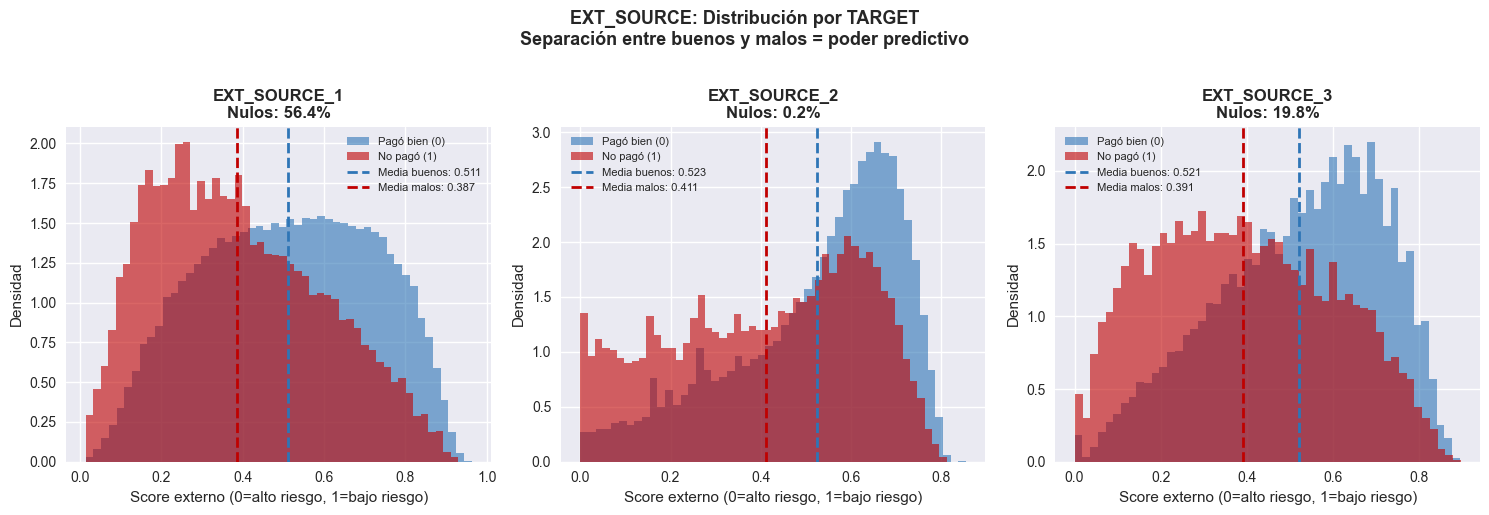


DIFERENCIA DE MEDIAS (buenos vs malos):
Cuanto mayor la diferencia, mayor el poder predictivo

  EXT_SOURCE_1: buenos=0.5115 | malos=0.3870 | diferencia=0.1245
  EXT_SOURCE_2: buenos=0.5235 | malos=0.4109 | diferencia=0.1125
  EXT_SOURCE_3: buenos=0.5210 | malos=0.3907 | diferencia=0.1303


In [16]:
# --- PODER PREDICTIVO DE EXT_SOURCE ---

# La pregunta clave: ¿los clientes malos tienen
# scores más bajos que los buenos?
# Si la respuesta es sí, la variable es predictiva.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # Separar distribución por TARGET
    buenos = df[df['TARGET'] == 0][col].dropna()  # Clientes que pagaron
    malos  = df[df['TARGET'] == 1][col].dropna()  # Clientes que no pagaron
    
    # Graficar distribución de cada grupo
    axes[i].hist(buenos, bins=50, alpha=0.6, color='#2E75B6',
                 label=f'Pagó bien (0)', density=True)
    axes[i].hist(malos,  bins=50, alpha=0.6, color='#C00000',
                 label=f'No pagó (1)', density=True)
    
    # Líneas de media por grupo
    axes[i].axvline(buenos.mean(), color='#2E75B6',
                    linestyle='--', linewidth=2,
                    label=f'Media buenos: {buenos.mean():.3f}')
    axes[i].axvline(malos.mean(),  color='#C00000',
                    linestyle='--', linewidth=2,
                    label=f'Media malos: {malos.mean():.3f}')
    
    axes[i].set_title(f'{col}\nNulos: {df[col].isna().mean()*100:.1f}%',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Score externo (0=alto riesgo, 1=bajo riesgo)')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

fig.suptitle('EXT_SOURCE: Distribución por TARGET\n'
             'Separación entre buenos y malos = poder predictivo',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/02_ext_source_poder_predictivo.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/02_ext_source_poder_predictivo.png")
plt.show()

# Mostrar diferencia de medias como indicador de poder predictivo
print("\nDIFERENCIA DE MEDIAS (buenos vs malos):")
print("="*60)
print("Cuanto mayor la diferencia, mayor el poder predictivo")
print()
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    media_buenos = df[df['TARGET']==0][col].mean()
    media_malos  = df[df['TARGET']==1][col].mean()
    diferencia   = media_buenos - media_malos
    print(f"  {col}: buenos={media_buenos:.4f} | "
          f"malos={media_malos:.4f} | "
          f"diferencia={diferencia:.4f}")

In [17]:
# --- CONSTRUCCIÓN DEL DTI (Debt-to-Income Ratio) ---

# El DTI es la variable más importante en crédito al consumo.
# Mide qué proporción del ingreso mensual compromete el cliente
# con el pago del crédito solicitado.

# IMPORTANTE: AMT_INCOME_TOTAL está en términos ANUALES
# AMT_ANNUITY es el pago MENSUAL del crédito
# Por eso dividimos el ingreso entre 12

df['INGRESO_MENSUAL'] = df['AMT_INCOME_TOTAL'] / 12

# DTI = Pago mensual del crédito / Ingreso mensual
df['DTI'] = df['AMT_ANNUITY'] / df['INGRESO_MENSUAL']

# Estadísticas básicas del DTI
print("ESTADÍSTICAS DEL DTI:")
print("="*60)
print(f"  Nulos:   {df['DTI'].isna().sum():>8,} ({df['DTI'].isna().mean()*100:.1f}%)")
print(f"  Media:   {df['DTI'].mean():>8.4f}")
print(f"  Mediana: {df['DTI'].median():>8.4f}")
print(f"  Min:     {df['DTI'].min():>8.4f}")
print(f"  Max:     {df['DTI'].max():>8.4f}")
print(f"  P25:     {df['DTI'].quantile(0.25):>8.4f}")
print(f"  P75:     {df['DTI'].quantile(0.75):>8.4f}")
print(f"  P90:     {df['DTI'].quantile(0.90):>8.4f}")
print(f"  P95:     {df['DTI'].quantile(0.95):>8.4f}")
print(f"  P99:     {df['DTI'].quantile(0.99):>8.4f}")

print()

# Diferencia de medias buenos vs malos
media_buenos = df[df['TARGET']==0]['DTI'].mean()
media_malos  = df[df['TARGET']==1]['DTI'].mean()
diferencia   = media_malos - media_buenos

print(f"  Media buenos: {media_buenos:.4f}")
print(f"  Media malos:  {media_malos:.4f}")
print(f"  Diferencia:   {diferencia:.4f}")
print()
print("  Interpretación:")
print(f"  Los clientes malos tienen en promedio")
print(f"  un DTI {diferencia:.4f} puntos mayor que los buenos")

C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\1369605910.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['INGRESO_MENSUAL'] = df['AMT_INCOME_TOTAL'] / 12
C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\1369605910.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DTI'] = df['AMT_ANNUITY'] / df['INGRESO_MENSUAL']


ESTADÍSTICAS DEL DTI:
  Nulos:         12 (0.0%)
  Media:     2.1712
  Mediana:   1.9540
  Min:       0.0027
  Max:      22.5116
  P25:       1.3774
  P75:       2.7488
  P90:       3.6197
  P95:       4.2560
  P99:       5.8015

  Media buenos: 2.1664
  Media malos:  2.2258
  Diferencia:   0.0594

  Interpretación:
  Los clientes malos tienen en promedio
  un DTI 0.0594 puntos mayor que los buenos


In [18]:
# --- INVESTIGAR LAS UNIDADES DE LAS VARIABLES ---

# Veamos los valores reales para entender las unidades

print("MUESTRA DE VALORES PARA ENTENDER UNIDADES:")
print("="*60)

# Ver las primeras 10 filas de las variables relevantes
cols_investigar = ['AMT_INCOME_TOTAL', 'AMT_CREDIT',
                   'AMT_ANNUITY', 'AMT_GOODS_PRICE']

print(df[cols_investigar].head(10).to_string())

print()
print("ESTADÍSTICAS DE AMT_INCOME_TOTAL:")
print(f"  Media:   {df['AMT_INCOME_TOTAL'].mean():>12,.0f}")
print(f"  Mediana: {df['AMT_INCOME_TOTAL'].median():>12,.0f}")
print(f"  Min:     {df['AMT_INCOME_TOTAL'].min():>12,.0f}")
print(f"  Max:     {df['AMT_INCOME_TOTAL'].max():>12,.0f}")

print()
print("ESTADÍSTICAS DE AMT_ANNUITY:")
print(f"  Media:   {df['AMT_ANNUITY'].mean():>12,.0f}")
print(f"  Mediana: {df['AMT_ANNUITY'].median():>12,.0f}")
print(f"  Min:     {df['AMT_ANNUITY'].min():>12,.0f}")
print(f"  Max:     {df['AMT_ANNUITY'].max():>12,.0f}")

print()
# Buscar la descripcion de AMT_INCOME_TOTAL en el diccionario
desc_income = vars_principales[
    vars_principales['Row'] == 'AMT_INCOME_TOTAL']['Description'].values[0]
desc_annuity = vars_principales[
    vars_principales['Row'] == 'AMT_ANNUITY']['Description'].values[0]

print(f"Descripción AMT_INCOME_TOTAL: {desc_income}")
print(f"Descripción AMT_ANNUITY:      {desc_annuity}")

MUESTRA DE VALORES PARA ENTENDER UNIDADES:
   AMT_INCOME_TOTAL   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
0       202500.0000  406597.5000   24700.5000      351000.0000
1       270000.0000 1293502.5000   35698.5000     1129500.0000
2        67500.0000  135000.0000    6750.0000      135000.0000
3       135000.0000  312682.5000   29686.5000      297000.0000
4       121500.0000  513000.0000   21865.5000      513000.0000
5        99000.0000  490495.5000   27517.5000      454500.0000
6       171000.0000 1560726.0000   41301.0000     1395000.0000
7       360000.0000 1530000.0000   42075.0000     1530000.0000
8       112500.0000 1019610.0000   33826.5000      913500.0000
9       135000.0000  405000.0000   20250.0000      405000.0000

ESTADÍSTICAS DE AMT_INCOME_TOTAL:
  Media:        168,798
  Mediana:      147,150
  Min:           25,650
  Max:      117,000,000

ESTADÍSTICAS DE AMT_ANNUITY:
  Media:         27,109
  Mediana:       24,903
  Min:            1,616
  Max:          258,026

Descri

In [19]:
# --- INVESTIGAR SI AMT_ANNUITY ES ANUAL O MENSUAL ---

# Si AMT_ANNUITY fuera mensual, el pago anual sería *12
# Comparemos con AMT_CREDIT para ver qué tiene más sentido

print("ANÁLISIS DE CONSISTENCIA AMT_ANNUITY:")
print("="*60)

# Para un crédito típico:
# Pago mensual * plazo (meses) ≈ monto del crédito
# (sin considerar intereses, es una aproximación)

df['PLAZO_ESTIMADO_MESES'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

print(f"Si AMT_ANNUITY es MENSUAL:")
print(f"  Plazo estimado media:   {df['PLAZO_ESTIMADO_MESES'].mean():.1f} meses")
print(f"  Plazo estimado mediana: {df['PLAZO_ESTIMADO_MESES'].median():.1f} meses")
print()

# Si es anual, el plazo sería en años
df['PLAZO_ESTIMADO_ANIOS'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
print(f"Si AMT_ANNUITY es ANUAL:")
print(f"  Plazo estimado media:   {df['PLAZO_ESTIMADO_ANIOS'].mean():.1f} años")
print(f"  Plazo estimado mediana: {df['PLAZO_ESTIMADO_ANIOS'].median():.1f} años")

print()
print("EJEMPLO CONCRETO (cliente 0):")
print(f"  Crédito:  {df['AMT_CREDIT'].iloc[0]:>12,.0f}")
print(f"  Annuity:  {df['AMT_ANNUITY'].iloc[0]:>12,.0f}")
print(f"  Ingreso:  {df['AMT_INCOME_TOTAL'].iloc[0]:>12,.0f}")
print(f"  Plazo si mensual: {df['AMT_CREDIT'].iloc[0]/df['AMT_ANNUITY'].iloc[0]:.1f} meses")
print(f"  Plazo si anual:   {df['AMT_CREDIT'].iloc[0]/df['AMT_ANNUITY'].iloc[0]:.1f} años")

ANÁLISIS DE CONSISTENCIA AMT_ANNUITY:
Si AMT_ANNUITY es MENSUAL:
  Plazo estimado media:   21.6 meses
  Plazo estimado mediana: 20.0 meses

Si AMT_ANNUITY es ANUAL:
  Plazo estimado media:   21.6 años
  Plazo estimado mediana: 20.0 años

EJEMPLO CONCRETO (cliente 0):
  Crédito:       406,598
  Annuity:        24,700
  Ingreso:       202,500
  Plazo si mensual: 16.5 meses
  Plazo si anual:   16.5 años


C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\408164207.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['PLAZO_ESTIMADO_MESES'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\408164207.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['PLAZO_ESTIMADO_ANIOS'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']


In [20]:
# --- VERIFICAR SI AMT_INCOME_TOTAL ES MENSUAL O ANUAL ---

print("INVESTIGACIÓN FINAL DE UNIDADES:")
print("="*60)

# Si el ingreso fuera mensual, el DTI sería:
dti_si_mensual = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

print(f"Si AMT_INCOME_TOTAL es MENSUAL:")
print(f"  DTI media:   {dti_si_mensual.mean():.4f}")
print(f"  DTI mediana: {dti_si_mensual.median():.4f}")
print(f"  DTI P90:     {dti_si_mensual.quantile(0.90):.4f}")
print(f"  DTI P99:     {dti_si_mensual.quantile(0.99):.4f}")
print()

# Si el ingreso fuera anual, el DTI sería:
dti_si_anual = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] / 12)

print(f"Si AMT_INCOME_TOTAL es ANUAL (divides entre 12):")
print(f"  DTI media:   {dti_si_anual.mean():.4f}")
print(f"  DTI mediana: {dti_si_anual.median():.4f}")
print(f"  DTI P90:     {dti_si_anual.quantile(0.90):.4f}")
print(f"  DTI P99:     {dti_si_anual.quantile(0.99):.4f}")
print()

# Ejemplo concreto cliente 0
print(f"CLIENTE 0:")
print(f"  Ingreso declarado:  {df['AMT_INCOME_TOTAL'].iloc[0]:>10,.0f}")
print(f"  Pago mensual:       {df['AMT_ANNUITY'].iloc[0]:>10,.0f}")
print(f"  DTI si ing. mensual: {df['AMT_ANNUITY'].iloc[0]/df['AMT_INCOME_TOTAL'].iloc[0]:.4f}")
print(f"  DTI si ing. anual:   {df['AMT_ANNUITY'].iloc[0]/(df['AMT_INCOME_TOTAL'].iloc[0]/12):.4f}")

INVESTIGACIÓN FINAL DE UNIDADES:
Si AMT_INCOME_TOTAL es MENSUAL:
  DTI media:   0.1809
  DTI mediana: 0.1628
  DTI P90:     0.3016
  DTI P99:     0.4835

Si AMT_INCOME_TOTAL es ANUAL (divides entre 12):
  DTI media:   2.1712
  DTI mediana: 1.9540
  DTI P90:     3.6197
  DTI P99:     5.8015

CLIENTE 0:
  Ingreso declarado:     202,500
  Pago mensual:           24,700
  DTI si ing. mensual: 0.1220
  DTI si ing. anual:   1.4637


In [21]:
# --- DTI CORREGIDO ---

# AMT_INCOME_TOTAL es MENSUAL (confirmado por análisis)
# AMT_ANNUITY es MENSUAL (confirmado por análisis)
# DTI = pago mensual / ingreso mensual

# Eliminar columnas incorrectas que creamos antes
df.drop(columns=['INGRESO_MENSUAL', 'DTI',
                 'PLAZO_ESTIMADO_MESES',
                 'PLAZO_ESTIMADO_ANIOS'], inplace=True)

# Crear DTI correcto
df['DTI'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Verificar
print("DTI CORREGIDO:")
print("="*60)
print(f"  Media:   {df['DTI'].mean():.4f}  ({df['DTI'].mean()*100:.1f}%)")
print(f"  Mediana: {df['DTI'].median():.4f}  ({df['DTI'].median()*100:.1f}%)")
print(f"  P75:     {df['DTI'].quantile(0.75):.4f}  ({df['DTI'].quantile(0.75)*100:.1f}%)")
print(f"  P90:     {df['DTI'].quantile(0.90):.4f}  ({df['DTI'].quantile(0.90)*100:.1f}%)")
print(f"  P99:     {df['DTI'].quantile(0.99):.4f}  ({df['DTI'].quantile(0.99)*100:.1f}%)")
print(f"  Max:     {df['DTI'].max():.4f}  ({df['DTI'].max()*100:.1f}%)")
print()

# Diferencia buenos vs malos
media_buenos = df[df['TARGET']==0]['DTI'].mean()
media_malos  = df[df['TARGET']==1]['DTI'].mean()
print(f"  Media buenos: {media_buenos:.4f} ({media_buenos*100:.1f}%)")
print(f"  Media malos:  {media_malos:.4f} ({media_malos*100:.1f}%)")
print(f"  Diferencia:   {(media_malos-media_buenos):.4f} puntos")
print()
print("  Interpretación:")
print(f"  El cliente promedio compromete el {df['DTI'].median()*100:.1f}%")
print(f"  de su ingreso mensual en el pago del crédito")

C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\3733854571.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DTI'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']


DTI CORREGIDO:
  Media:   0.1809  (18.1%)
  Mediana: 0.1628  (16.3%)
  P75:     0.2291  (22.9%)
  P90:     0.3016  (30.2%)
  P99:     0.4835  (48.3%)
  Max:     1.8760  (187.6%)

  Media buenos: 0.1805 (18.1%)
  Media malos:  0.1855 (18.5%)
  Diferencia:   0.0050 puntos

  Interpretación:
  El cliente promedio compromete el 16.3%
  de su ingreso mensual en el pago del crédito


Gráfica guardada en reports/03_dti_analisis.png


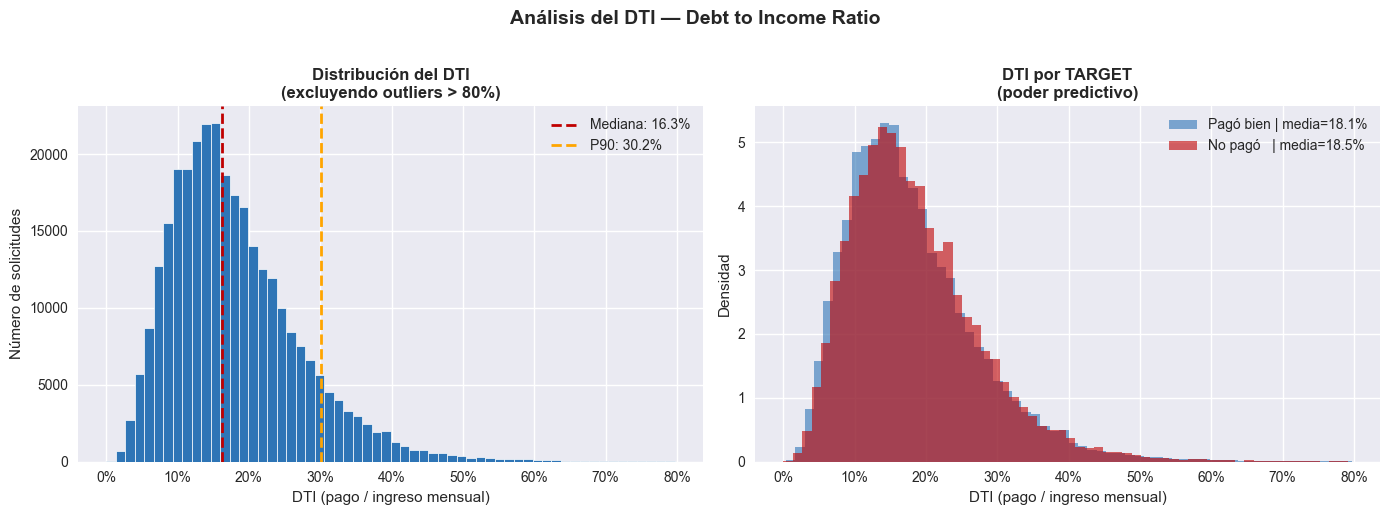

In [22]:
# --- GRÁFICA DEL DTI ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICA 1: Distribución general del DTI
# Limitamos a DTI < 0.8 para ver mejor la distribución
# (los outliers extremos distorsionan la gráfica)
dti_filtrado = df[df['DTI'] < 0.8]['DTI']

axes[0].hist(dti_filtrado, bins=60,
             color='#2E75B6', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['DTI'].median(), color='#C00000',
                linestyle='--', linewidth=2,
                label=f"Mediana: {df['DTI'].median()*100:.1f}%")
axes[0].axvline(df['DTI'].quantile(0.90), color='orange',
                linestyle='--', linewidth=2,
                label=f"P90: {df['DTI'].quantile(0.90)*100:.1f}%")
axes[0].set_title('Distribución del DTI\n(excluyendo outliers > 80%)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('DTI (pago / ingreso mensual)')
axes[0].set_ylabel('Número de solicitudes')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[0].legend()

# GRÁFICA 2: DTI por TARGET
buenos = df[df['TARGET']==0]['DTI']
malos  = df[df['TARGET']==1]['DTI']

axes[1].hist(buenos[buenos < 0.8], bins=60,
             alpha=0.6, color='#2E75B6',
             label=f'Pagó bien | media={buenos.mean()*100:.1f}%',
             density=True)
axes[1].hist(malos[malos < 0.8], bins=60,
             alpha=0.6, color='#C00000',
             label=f'No pagó   | media={malos.mean()*100:.1f}%',
             density=True)
axes[1].set_title('DTI por TARGET\n(poder predictivo)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('DTI (pago / ingreso mensual)')
axes[1].set_ylabel('Densidad')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[1].legend()

fig.suptitle('Análisis del DTI — Debt to Income Ratio',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/03_dti_analisis.png', dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/03_dti_analisis.png")
plt.show()

In [23]:
# --- ANÁLISIS DE VALORES FALTANTES (MISSINGS) ---

# Los valores faltantes en crédito NO son aleatorios.
# Su ausencia es información en sí misma.
# Ejemplo: sin historial en Buró = cliente nuevo al sistema financiero

# Calcular nulos por columna
nulos = pd.DataFrame({
    'variable': df.columns,
    'nulos_count': df.isnull().sum().values,
    'nulos_pct': (df.isnull().sum() / len(df) * 100).values
})

# Ordenar de mayor a menor
nulos = nulos.sort_values('nulos_pct', ascending=False)

# Filtrar solo variables CON nulos
nulos_existentes = nulos[nulos['nulos_count'] > 0].copy()

print("VARIABLES CON VALORES FALTANTES:")
print("="*60)
print(f"Variables sin ningún nulo:    {(nulos['nulos_count']==0).sum()}")
print(f"Variables con algún nulo:     {(nulos['nulos_count']>0).sum()}")
print(f"Total variables:              {len(nulos)}")
print()

# Clasificar por severidad
nulos_existentes['severidad'] = pd.cut(
    nulos_existentes['nulos_pct'],
    bins=[0, 5, 20, 50, 100],
    labels=['Leve (<5%)', 'Moderado (5-20%)',
            'Alto (20-50%)', 'Crítico (>50%)']
)

print("DISTRIBUCIÓN POR SEVERIDAD:")
print(nulos_existentes['severidad'].value_counts().to_string())
print()
print("TOP 20 VARIABLES CON MÁS NULOS:")
print(nulos_existentes[['variable','nulos_count','nulos_pct','severidad']]
      .head(20).to_string(index=False))

VARIABLES CON VALORES FALTANTES:
Variables sin ningún nulo:    55
Variables con algún nulo:     68
Total variables:              123

DISTRIBUCIÓN POR SEVERIDAD:
severidad
Crítico (>50%)      41
Leve (<5%)          11
Alto (20-50%)        9
Moderado (5-20%)     7

TOP 20 VARIABLES CON MÁS NULOS:
                variable  nulos_count  nulos_pct      severidad
          COMMONAREA_AVG       214865    69.8723 Crítico (>50%)
         COMMONAREA_MEDI       214865    69.8723 Crítico (>50%)
         COMMONAREA_MODE       214865    69.8723 Crítico (>50%)
NONLIVINGAPARTMENTS_MODE       213514    69.4330 Crítico (>50%)
NONLIVINGAPARTMENTS_MEDI       213514    69.4330 Crítico (>50%)
 NONLIVINGAPARTMENTS_AVG       213514    69.4330 Crítico (>50%)
      FONDKAPREMONT_MODE       210295    68.3862 Crítico (>50%)
   LIVINGAPARTMENTS_MEDI       210199    68.3550 Crítico (>50%)
   LIVINGAPARTMENTS_MODE       210199    68.3550 Crítico (>50%)
    LIVINGAPARTMENTS_AVG       210199    68.3550 Crítico (>50%)

Gráfica guardada en reports/04_missings_analisis.png


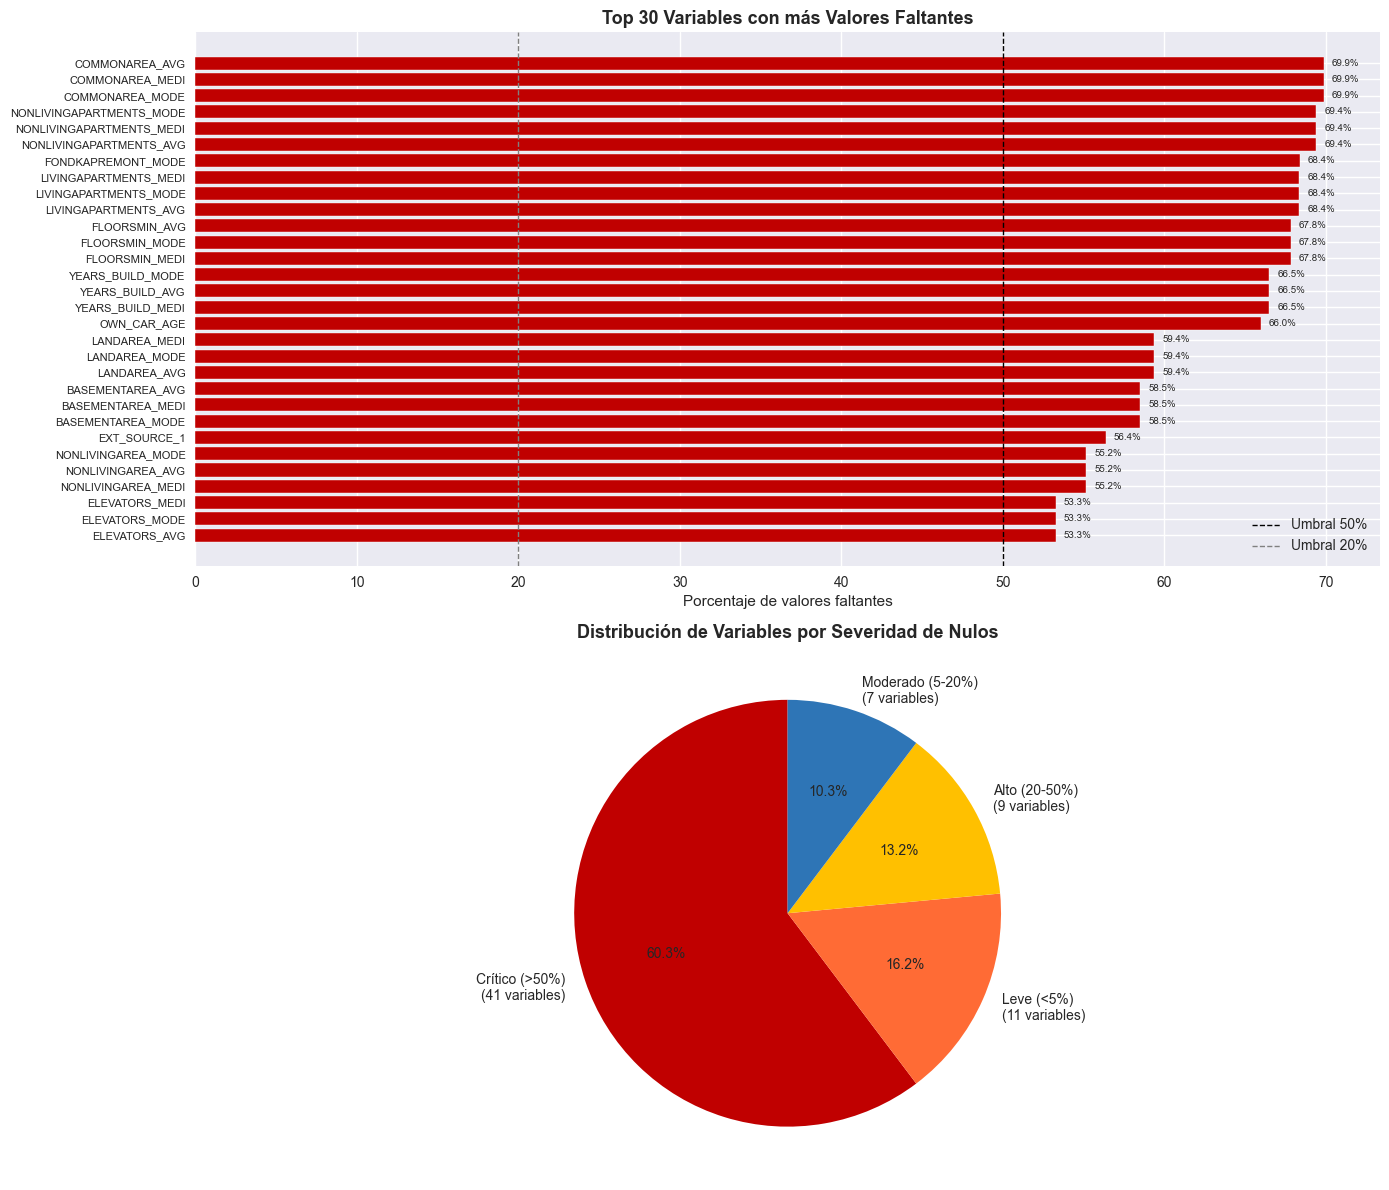


ESTRATEGIA DE TRATAMIENTO:
Crítico  (>50%): Candidatas a DESCARTAR del modelo
                 Principalmente variables de edificio
Alto   (20-50%): Evaluar poder predictivo antes de decidir
                 EXT_SOURCE_1 (56%) merece excepción
Moderado (5-20%): Imputar con mediana por segmento
Leve     (<5%):  Imputar con mediana simple


In [24]:
# --- GRÁFICA DE VALORES FALTANTES ---

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# GRÁFICA 1: Top 30 variables con más nulos
top30 = nulos_existentes.head(30)

colores_severidad = {
    'Crítico (>50%)':     '#C00000',
    'Alto (20-50%)':      '#FF6B35',
    'Moderado (5-20%)':   '#FFC000',
    'Leve (<5%)':         '#2E75B6'
}

barras_colores = [colores_severidad[s] for s in top30['severidad']]

axes[0].barh(
    range(len(top30)),
    top30['nulos_pct'],
    color=barras_colores,
    edgecolor='white'
)
axes[0].set_yticks(range(len(top30)))
axes[0].set_yticklabels(top30['variable'], fontsize=8)
axes[0].axvline(50, color='black', linestyle='--',
                linewidth=1, label='Umbral 50%')
axes[0].axvline(20, color='gray', linestyle='--',
                linewidth=1, label='Umbral 20%')
axes[0].set_xlabel('Porcentaje de valores faltantes')
axes[0].set_title('Top 30 Variables con más Valores Faltantes',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()  # Variable con más nulos arriba

# Agregar porcentaje en cada barra
for i, (_, row) in enumerate(top30.iterrows()):
    axes[0].text(row['nulos_pct'] + 0.5, i,
                f"{row['nulos_pct']:.1f}%",
                va='center', fontsize=7)

# GRÁFICA 2: Resumen por severidad
severidad_counts = nulos_existentes['severidad'].value_counts()
colores_pie = ['#C00000', '#FF6B35', '#FFC000', '#2E75B6']

axes[1].pie(
    severidad_counts.values,
    labels=[f'{s}\n({n} variables)'
            for s, n in severidad_counts.items()],
    colors=colores_pie,
    startangle=90,
    autopct='%1.1f%%',
    textprops={'fontsize': 10}
)
axes[1].set_title('Distribución de Variables por Severidad de Nulos',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/04_missings_analisis.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/04_missings_analisis.png")
plt.show()

# Resumen estratégico
print("\nESTRATEGIA DE TRATAMIENTO:")
print("="*60)
print("Crítico  (>50%): Candidatas a DESCARTAR del modelo")
print("                 Principalmente variables de edificio")
print("Alto   (20-50%): Evaluar poder predictivo antes de decidir")
print("                 EXT_SOURCE_1 (56%) merece excepción")
print("Moderado (5-20%): Imputar con mediana por segmento")
print("Leve     (<5%):  Imputar con mediana simple")

In [25]:
# --- ANÁLISIS DE VARIABLES DE TIEMPO ---

# Home Credit almacena las fechas como DÍAS NEGATIVOS
# contados hacia atrás desde la fecha de solicitud.
#
# Ejemplo: DAYS_BIRTH = -12000
# Significa que el cliente nació hace 12,000 días
# (aproximadamente 32 años)
#
# ¿Por qué negativo? Porque es la distancia en días
# desde HOY hacia el PASADO.

print("VARIABLES DE TIEMPO EN EL DATASET:")
print("="*60)

vars_tiempo = ['DAYS_BIRTH', 'DAYS_EMPLOYED',
               'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']

for col in vars_tiempo:
    print(f"\n{col}:")
    print(f"  Min:     {df[col].min():>10,.0f} días")
    print(f"  Max:     {df[col].max():>10,.0f} días")
    print(f"  Media:   {df[col].mean():>10,.0f} días")
    print(f"  Nulos:   {df[col].isna().sum():>10,}")

VARIABLES DE TIEMPO EN EL DATASET:

DAYS_BIRTH:
  Min:        -25,229 días
  Max:         -7,489 días
  Media:      -16,037 días
  Nulos:            0

DAYS_EMPLOYED:
  Min:        -17,912 días
  Max:        365,243 días
  Media:       63,815 días
  Nulos:            0

DAYS_REGISTRATION:
  Min:        -24,672 días
  Max:              0 días
  Media:       -4,986 días
  Nulos:            0

DAYS_ID_PUBLISH:
  Min:         -7,197 días
  Max:              0 días
  Media:       -2,994 días
  Nulos:            0


In [26]:
# --- INVESTIGAR ANOMALÍA EN DAYS_EMPLOYED ---

print("INVESTIGACIÓN DE DAYS_EMPLOYED:")
print("="*60)

# ¿Cuántos registros tienen el valor anómalo 365243?
anomalos = (df['DAYS_EMPLOYED'] == 365243).sum()
print(f"\nRegistros con valor 365243: {anomalos:,} ({anomalos/len(df)*100:.1f}%)")

# ¿Qué tipo de ingreso tienen estos clientes?
print("\nTipo de ingreso de clientes con DAYS_EMPLOYED=365243:")
print(df[df['DAYS_EMPLOYED']==365243]['NAME_INCOME_TYPE']
      .value_counts().to_string())

# ¿Cuál es su tasa de mora?
mora_anomalos = df[df['DAYS_EMPLOYED']==365243]['TARGET'].mean()
mora_normales = df[df['DAYS_EMPLOYED']!=365243]['TARGET'].mean()
print(f"\nTasa de mora con valor 365243:  {mora_anomalos*100:.2f}%")
print(f"Tasa de mora valores normales:  {mora_normales*100:.2f}%")

INVESTIGACIÓN DE DAYS_EMPLOYED:

Registros con valor 365243: 55,374 (18.0%)

Tipo de ingreso de clientes con DAYS_EMPLOYED=365243:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22

Tasa de mora con valor 365243:  5.40%
Tasa de mora valores normales:  8.66%


In [27]:
# --- CONVERSIÓN DE VARIABLES DE TIEMPO ---

# DAYS_BIRTH → Edad en años (valor positivo, más intuitivo)
df['EDAD_AÑOS'] = (-df['DAYS_BIRTH'] / 365).astype(int)

# DAYS_EMPLOYED → Antigüedad laboral en años
# Primero tratamos el valor centinela 365243
# Lo reemplazamos con NaN (es información faltante real)
df['DAYS_EMPLOYED_LIMPIO'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Convertir a años positivos
df['ANTIGUEDAD_LABORAL_AÑOS'] = (-df['DAYS_EMPLOYED_LIMPIO'] / 365)

# Crear flag que indica si es pensionado/desempleado
# Esta es información valiosa que no queremos perder
df['FLAG_PENSIONADO_DESEMPLEADO'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Verificar resultados
print("VARIABLES DE TIEMPO CONVERTIDAS:")
print("="*60)

print(f"\nEDAD_AÑOS:")
print(f"  Min:     {df['EDAD_AÑOS'].min()} años")
print(f"  Max:     {df['EDAD_AÑOS'].max()} años")
print(f"  Media:   {df['EDAD_AÑOS'].mean():.1f} años")
print(f"  Mediana: {df['EDAD_AÑOS'].median():.1f} años")

print(f"\nANTIGUEDAD_LABORAL_AÑOS (sin centinela):")
print(f"  Min:     {df['ANTIGUEDAD_LABORAL_AÑOS'].min():.1f} años")
print(f"  Max:     {df['ANTIGUEDAD_LABORAL_AÑOS'].max():.1f} años")
print(f"  Media:   {df['ANTIGUEDAD_LABORAL_AÑOS'].mean():.1f} años")
print(f"  Nulos:   {df['ANTIGUEDAD_LABORAL_AÑOS'].isna().sum():,} "
      f"({df['ANTIGUEDAD_LABORAL_AÑOS'].isna().mean()*100:.1f}%)")

print(f"\nFLAG_PENSIONADO_DESEMPLEADO:")
print(f"  Total:   {df['FLAG_PENSIONADO_DESEMPLEADO'].sum():,} clientes")
print(f"  Mora:    {df[df['FLAG_PENSIONADO_DESEMPLEADO']==1]['TARGET'].mean()*100:.2f}%")

# Diferencia de medias buenos vs malos para EDAD
media_edad_buenos = df[df['TARGET']==0]['EDAD_AÑOS'].mean()
media_edad_malos  = df[df['TARGET']==1]['EDAD_AÑOS'].mean()
print(f"\nEDAD promedio buenos: {media_edad_buenos:.1f} años")
print(f"EDAD promedio malos:  {media_edad_malos:.1f} años")
print(f"Diferencia:           {media_edad_buenos - media_edad_malos:.1f} años")

C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\166360003.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['EDAD_AÑOS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\166360003.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DAYS_EMPLOYED_LIMPIO'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\166360003.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

VARIABLES DE TIEMPO CONVERTIDAS:

EDAD_AÑOS:
  Min:     20 años
  Max:     69 años
  Media:   43.4 años
  Mediana: 43.0 años

ANTIGUEDAD_LABORAL_AÑOS (sin centinela):
  Min:     -0.0 años
  Max:     49.1 años
  Media:   6.5 años
  Nulos:   55,374 (18.0%)

FLAG_PENSIONADO_DESEMPLEADO:
  Total:   55,374 clientes
  Mora:    5.40%

EDAD promedio buenos: 43.7 años
EDAD promedio malos:  40.3 años
Diferencia:           3.4 años


In [28]:
# --- DESFRAGMENTAR EL DATAFRAME ---

# El PerformanceWarning indica que el DataFrame
# está fragmentado internamente por agregar
# columnas una a una. Hacemos una copia limpia.

print(f"Columnas antes: {df.shape[1]}")

df = df.copy()

print(f"Columnas después: {df.shape[1]}")
print("DataFrame desfragmentado ✅")
print("El PerformanceWarning no aparecerá más")

Columnas antes: 127
Columnas después: 127
DataFrame desfragmentado ✅
El PerformanceWarning no aparecerá más


Gráfica guardada


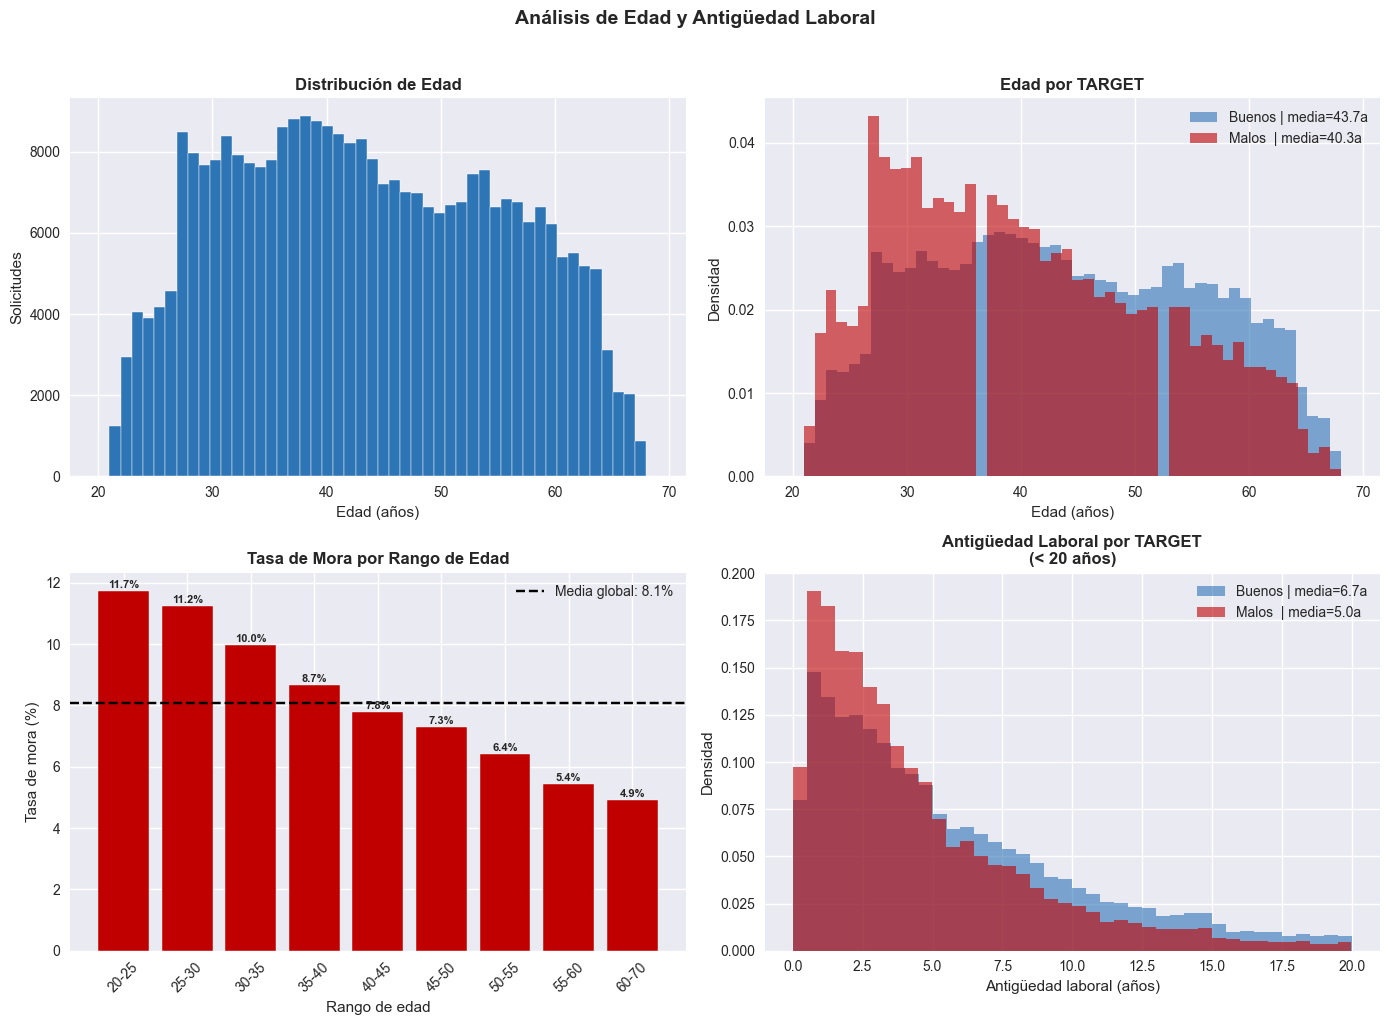


PODER PREDICTIVO:
Edad     → diferencia buenos vs malos: 3.4 años
Antigüedad → diferencia buenos vs malos: 1.7 años


In [29]:
# --- GRÁFICA DE EDAD Y ANTIGÜEDAD LABORAL ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# GRÁFICA 1: Distribución de edad
axes[0,0].hist(df['EDAD_AÑOS'], bins=50,
               color='#2E75B6', edgecolor='white')
axes[0,0].set_title('Distribución de Edad', fontweight='bold')
axes[0,0].set_xlabel('Edad (años)')
axes[0,0].set_ylabel('Solicitudes')

# GRÁFICA 2: Edad por TARGET
buenos_edad = df[df['TARGET']==0]['EDAD_AÑOS']
malos_edad  = df[df['TARGET']==1]['EDAD_AÑOS']

axes[0,1].hist(buenos_edad, bins=50, alpha=0.6,
               color='#2E75B6', density=True,
               label=f'Buenos | media={buenos_edad.mean():.1f}a')
axes[0,1].hist(malos_edad, bins=50, alpha=0.6,
               color='#C00000', density=True,
               label=f'Malos  | media={malos_edad.mean():.1f}a')
axes[0,1].set_title('Edad por TARGET', fontweight='bold')
axes[0,1].set_xlabel('Edad (años)')
axes[0,1].set_ylabel('Densidad')
axes[0,1].legend()

# GRÁFICA 3: Tasa de mora por grupo de edad
# Creamos rangos de edad para ver la tendencia
df['RANGO_EDAD'] = pd.cut(df['EDAD_AÑOS'],
                           bins=[20,25,30,35,40,45,50,55,60,70],
                           labels=['20-25','25-30','30-35','35-40',
                                   '40-45','45-50','50-55','55-60','60-70'])

mora_por_edad = df.groupby('RANGO_EDAD', observed=True)['TARGET'].mean() * 100

axes[1,0].bar(range(len(mora_por_edad)),
              mora_por_edad.values,
              color='#C00000', edgecolor='white')
axes[1,0].set_xticks(range(len(mora_por_edad)))
axes[1,0].set_xticklabels(mora_por_edad.index, rotation=45)
axes[1,0].axhline(df['TARGET'].mean()*100, color='black',
                  linestyle='--', label=f'Media global: {df["TARGET"].mean()*100:.1f}%')
axes[1,0].set_title('Tasa de Mora por Rango de Edad', fontweight='bold')
axes[1,0].set_xlabel('Rango de edad')
axes[1,0].set_ylabel('Tasa de mora (%)')
axes[1,0].legend()

# Agregar valores encima de cada barra
for i, v in enumerate(mora_por_edad.values):
    axes[1,0].text(i, v + 0.1, f'{v:.1f}%',
                   ha='center', fontsize=8, fontweight='bold')

# GRÁFICA 4: Antigüedad laboral por TARGET
antiguedad_buenos = df[df['TARGET']==0]['ANTIGUEDAD_LABORAL_AÑOS'].dropna()
antiguedad_malos  = df[df['TARGET']==1]['ANTIGUEDAD_LABORAL_AÑOS'].dropna()

axes[1,1].hist(antiguedad_buenos[antiguedad_buenos < 20],
               bins=40, alpha=0.6, color='#2E75B6', density=True,
               label=f'Buenos | media={antiguedad_buenos.mean():.1f}a')
axes[1,1].hist(antiguedad_malos[antiguedad_malos < 20],
               bins=40, alpha=0.6, color='#C00000', density=True,
               label=f'Malos  | media={antiguedad_malos.mean():.1f}a')
axes[1,1].set_title('Antigüedad Laboral por TARGET\n(< 20 años)',
                    fontweight='bold')
axes[1,1].set_xlabel('Antigüedad laboral (años)')
axes[1,1].set_ylabel('Densidad')
axes[1,1].legend()

fig.suptitle('Análisis de Edad y Antigüedad Laboral',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/05_edad_antiguedad_analisis.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada")
plt.show()

# Resumen de poder predictivo
print("\nPODER PREDICTIVO:")
print("="*60)
print(f"Edad     → diferencia buenos vs malos: "
      f"{buenos_edad.mean()-malos_edad.mean():.1f} años")
print(f"Antigüedad → diferencia buenos vs malos: "
      f"{antiguedad_buenos.mean()-antiguedad_malos.mean():.1f} años")

In [30]:
# --- ANÁLISIS DE VARIABLES CATEGÓRICAS ---

# Las variables categóricas (texto) necesitan
# análisis especial porque no tienen orden numérico.
# Para el modelo hay que convertirlas a números
# usando WoE o encoding.

# Identificar variables categóricas
vars_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("VARIABLES CATEGÓRICAS:")
print("="*60)
print(f"Total: {len(vars_categoricas)}")
print()

# Para cada variable categórica mostrar:
# categorías únicas y tasa de mora por categoría
for col in vars_categoricas:
    n_categorias = df[col].nunique()
    print(f"\n{col} ({n_categorias} categorías):")
    
    # Tasa de mora por categoría ordenada de mayor a menor
    mora_por_cat = (df.groupby(col, observed=True)['TARGET']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'tasa_mora', 'count': 'n'})
                    .sort_values('tasa_mora', ascending=False))
    
    mora_por_cat['tasa_mora_pct'] = mora_por_cat['tasa_mora'] * 100
    mora_por_cat['pct_total'] = mora_por_cat['n'] / len(df) * 100
    
    print(mora_por_cat[['n', 'pct_total', 'tasa_mora_pct']]
          .to_string(float_format='{:.2f}'.format))

C:\Users\Marin\AppData\Local\Temp\ipykernel_9876\1553162683.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_categoricas = df.select_dtypes(include=['object']).columns.tolist()


VARIABLES CATEGÓRICAS:
Total: 16


NAME_CONTRACT_TYPE (2 categorías):
                         n  pct_total  tasa_mora_pct
NAME_CONTRACT_TYPE                                  
Cash loans          278232      90.48           8.35
Revolving loans      29279       9.52           5.48

CODE_GENDER (3 categorías):
                  n  pct_total  tasa_mora_pct
CODE_GENDER                                  
M            105059      34.16          10.14
F            202448      65.83           7.00
XNA               4       0.00           0.00

FLAG_OWN_CAR (2 categorías):
                   n  pct_total  tasa_mora_pct
FLAG_OWN_CAR                                  
N             202924      65.99           8.50
Y             104587      34.01           7.24

FLAG_OWN_REALTY (2 categorías):
                      n  pct_total  tasa_mora_pct
FLAG_OWN_REALTY                                  
N                 94199      30.63           8.32
Y                213312      69.37           7.96

NAME_TY

Gráfica guardada en reports/06_categoricas_mora.png


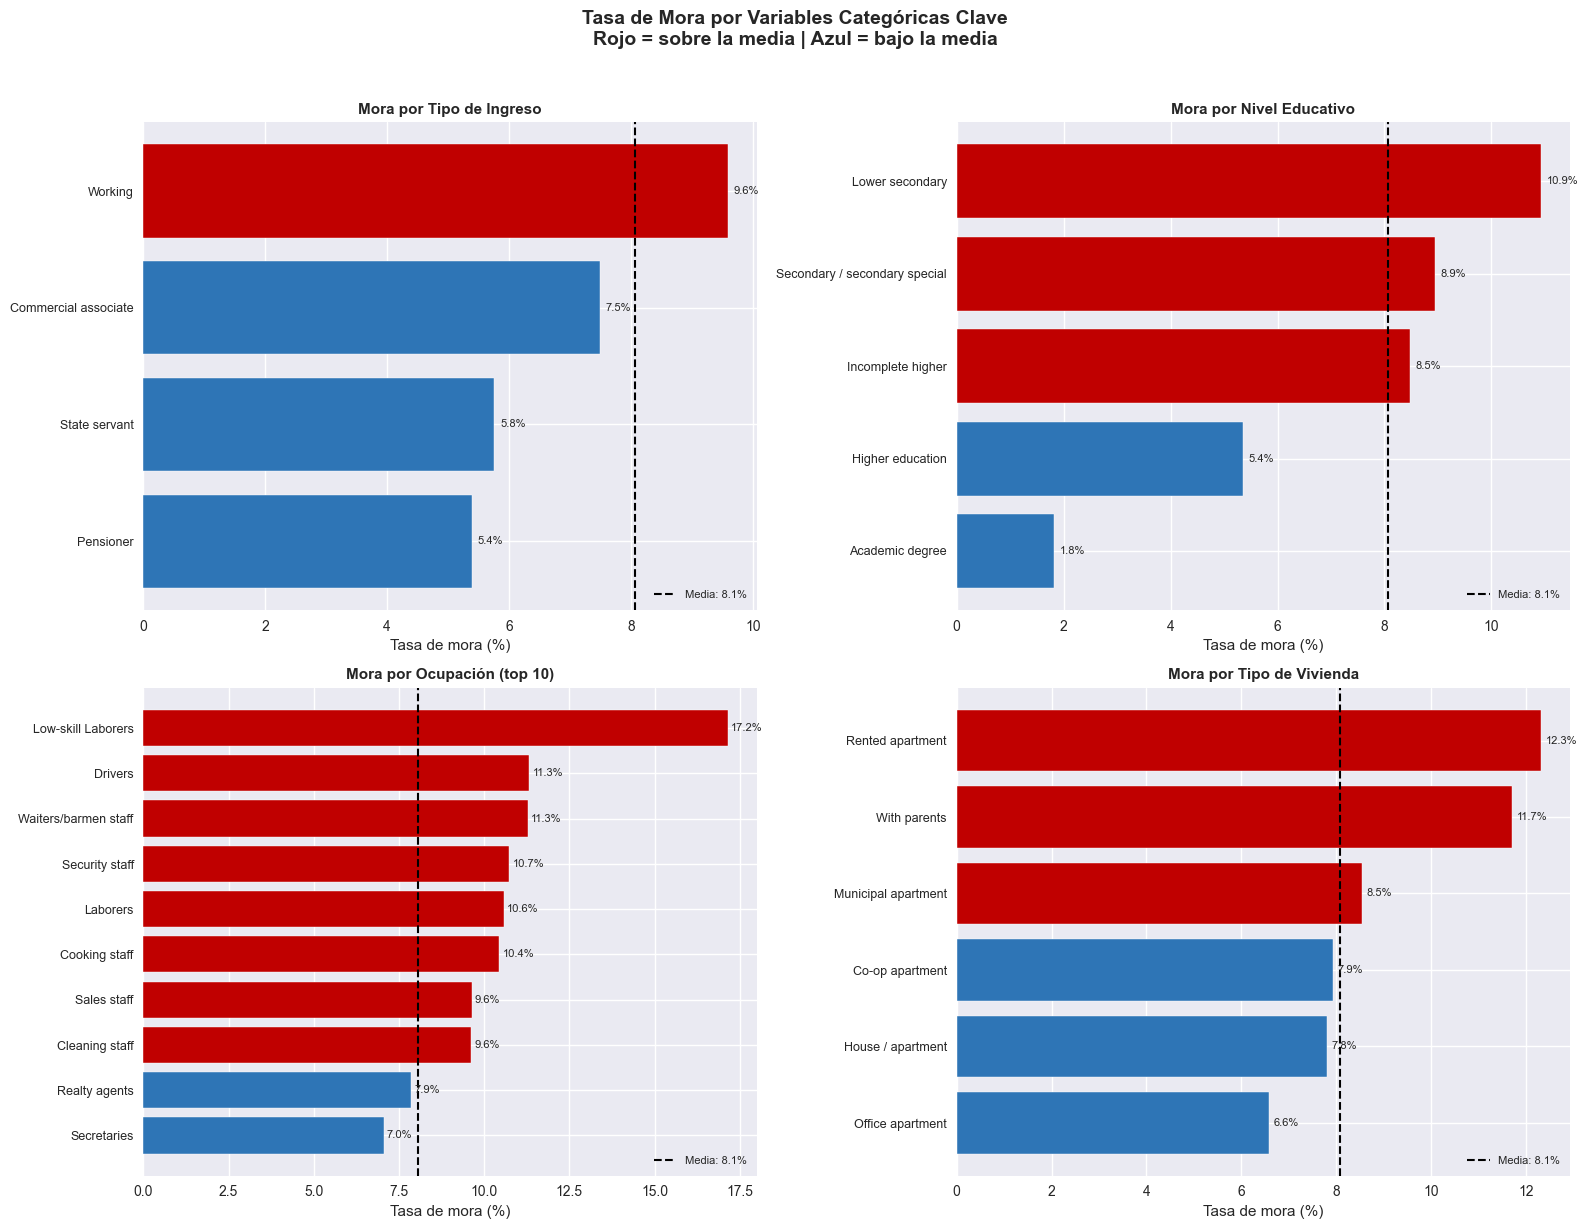

In [31]:
# --- GRÁFICA DE VARIABLES CATEGÓRICAS CLAVE ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Función auxiliar para graficar mora por categoría
def graficar_mora_categoria(ax, columna, titulo, max_cats=10):
    mora = (df.groupby(columna, observed=True)['TARGET']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'mora', 'count': 'n'})
              .sort_values('mora', ascending=True))
    
    # Filtrar categorías con muy pocos casos (< 100)
    mora = mora[mora['n'] >= 100].tail(max_cats)
    
    colores = ['#C00000' if m > df['TARGET'].mean()
               else '#2E75B6' for m in mora['mora']]
    
    bars = ax.barh(range(len(mora)), mora['mora']*100,
                   color=colores, edgecolor='white')
    ax.set_yticks(range(len(mora)))
    ax.set_yticklabels(mora.index, fontsize=9)
    ax.axvline(df['TARGET'].mean()*100, color='black',
               linestyle='--', linewidth=1.5,
               label=f'Media: {df["TARGET"].mean()*100:.1f}%')
    ax.set_xlabel('Tasa de mora (%)')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    
    # Agregar valores en las barras
    for i, (_, row) in enumerate(mora.iterrows()):
        ax.text(row['mora']*100 + 0.1, i,
                f"{row['mora']*100:.1f}%",
                va='center', fontsize=8)

graficar_mora_categoria(axes[0,0], 'NAME_INCOME_TYPE',
                        'Mora por Tipo de Ingreso')
graficar_mora_categoria(axes[0,1], 'NAME_EDUCATION_TYPE',
                        'Mora por Nivel Educativo')
graficar_mora_categoria(axes[1,0], 'OCCUPATION_TYPE',
                        'Mora por Ocupación (top 10)')
graficar_mora_categoria(axes[1,1], 'NAME_HOUSING_TYPE',
                        'Mora por Tipo de Vivienda')

fig.suptitle('Tasa de Mora por Variables Categóricas Clave\n'
             'Rojo = sobre la media | Azul = bajo la media',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/06_categoricas_mora.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/06_categoricas_mora.png")
plt.show()

In [32]:
# --- ANÁLISIS DE CORRELACIÓN CON EL TARGET ---

# La correlación mide la relación lineal entre
# cada variable numérica y el TARGET.
#
# Valores cercanos a +1: variable sube cuando hay mora
# Valores cercanos a -1: variable baja cuando hay mora
# Valores cercanos a  0: poca relación lineal
#
# IMPORTANTE: correlación baja no significa que la variable
# sea inútil. Variables no lineales pueden tener correlación
# baja pero alto poder predictivo (como EXT_SOURCE)

# Seleccionar solo variables numéricas
vars_numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Calcular correlación con TARGET
correlaciones = (df[vars_numericas]
                 .corr()['TARGET']
                 .drop('TARGET')  # quitar la correlación de TARGET consigo mismo
                 .sort_values(key=abs, ascending=False))

print("TOP 20 VARIABLES MÁS CORRELACIONADAS CON EL TARGET:")
print("="*60)
print(correlaciones.head(20).to_string())
print()
print("VARIABLES MÁS CORRELACIONADAS NEGATIVAMENTE:")
print(correlaciones.tail(10).to_string())

TOP 20 VARIABLES MÁS CORRELACIONADAS CON EL TARGET:
EXT_SOURCE_3                  -0.1789
EXT_SOURCE_2                  -0.1605
EXT_SOURCE_1                  -0.1553
DAYS_BIRTH                     0.0782
EDAD_AÑOS                     -0.0782
DAYS_EMPLOYED_LIMPIO           0.0750
ANTIGUEDAD_LABORAL_AÑOS       -0.0750
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_PENSIONADO_DESEMPLEADO   -0.0460
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                 -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                 -0.0440
FLOORSMAX_MEDI                -0.0438
FLOORSMAX_MODE                -0.0432

VARIABLES MÁS CORRELACIONADAS NEGATIVAMENTE:
FLAG_DOCUMENT_7              -0.0015
FLAG_DOCUMENT_10             -0.0014
FLAG_DOCUMENT_19             -0.0014
AMT_REQ_CREDIT_BUREAU_HOUR    0

Gráfica guardada en reports/07_correlaciones_target.png


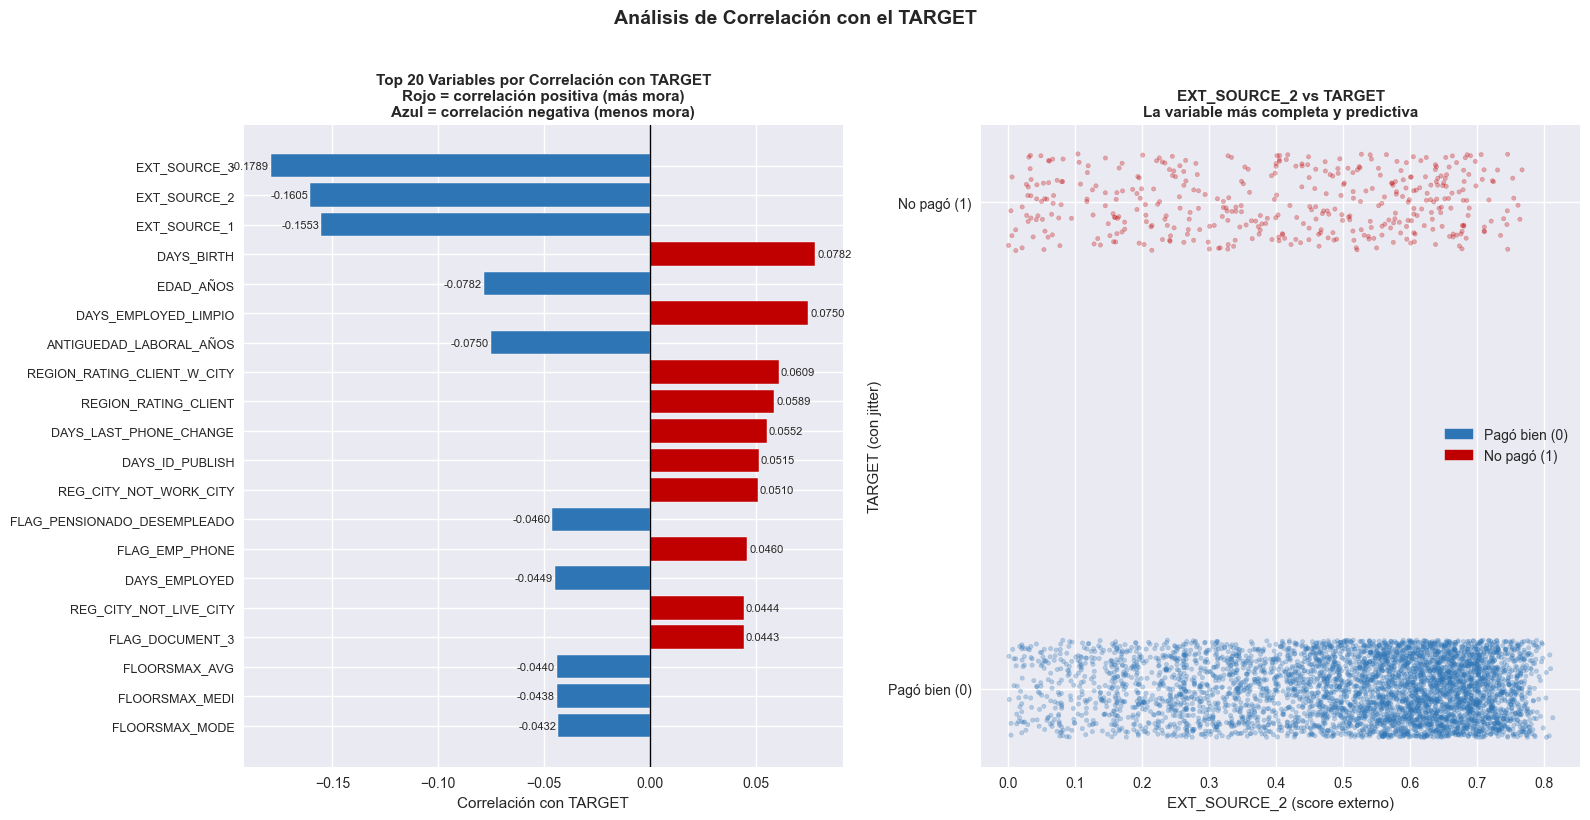

In [33]:
# --- GRÁFICA DE CORRELACIONES ---

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# GRÁFICA 1: Top 20 correlaciones (positivas y negativas)
top20 = correlaciones.head(20)

colores = ['#C00000' if c > 0 else '#2E75B6'
           for c in top20.values]

axes[0].barh(range(len(top20)), top20.values,
             color=colores, edgecolor='white')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=9)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Correlación con TARGET')
axes[0].set_title('Top 20 Variables por Correlación con TARGET\n'
                  'Rojo = correlación positiva (más mora)\n'
                  'Azul = correlación negativa (menos mora)',
                  fontweight='bold', fontsize=11)
axes[0].invert_yaxis()

# Agregar valores
for i, v in enumerate(top20.values):
    axes[0].text(v + 0.001 if v >= 0 else v - 0.001,
                 i, f'{v:.4f}',
                 va='center', ha='left' if v >= 0 else 'right',
                 fontsize=8)

# GRÁFICA 2: Scatter EXT_SOURCE_2 vs TARGET
# Con jitter para ver mejor la distribución
np.random.seed(42)
jitter = np.random.uniform(-0.1, 0.1, len(df))

# Muestra de 5000 puntos para no saturar la gráfica
muestra = df.sample(5000, random_state=42)
jitter_muestra = np.random.uniform(-0.1, 0.1, len(muestra))

colores_scatter = ['#C00000' if t == 1 else '#2E75B6'
                   for t in muestra['TARGET']]

axes[1].scatter(muestra['EXT_SOURCE_2'],
                muestra['TARGET'] + jitter_muestra,
                c=colores_scatter, alpha=0.3, s=10)
axes[1].set_xlabel('EXT_SOURCE_2 (score externo)')
axes[1].set_ylabel('TARGET (con jitter)')
axes[1].set_title('EXT_SOURCE_2 vs TARGET\n'
                  'La variable más completa y predictiva',
                  fontweight='bold', fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Pagó bien (0)', 'No pagó (1)'])

from matplotlib.patches import Patch
leyenda = [Patch(color='#2E75B6', label='Pagó bien (0)'),
           Patch(color='#C00000', label='No pagó (1)')]
axes[1].legend(handles=leyenda)

fig.suptitle('Análisis de Correlación con el TARGET',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/07_correlaciones_target.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/07_correlaciones_target.png")
plt.show()

In [34]:
# --- RESUMEN FINAL DEL EDA ---

print("="*65)
print("RESUMEN EJECUTIVO DEL EDA")
print("Credit Risk Scoring ML — Home Credit Default Risk")
print("="*65)

print(f"""
DATASET:
    Filas:    {df.shape[0]:,}
    Columnas: {df.shape[1]:,}
    Memoria:  ~286 MB

TARGET:
    Buenos (pagó):  {(df['TARGET']==0).sum():,} ({(df['TARGET']==0).mean()*100:.1f}%)
    Malos (mora):   {(df['TARGET']==1).sum():,} ({(df['TARGET']==1).mean()*100:.1f}%)
    Ratio:          {(df['TARGET']==0).sum()/(df['TARGET']==1).sum():.1f}:1
    Técnica:        class_weight o scale_pos_weight = {(df['TARGET']==0).sum()/(df['TARGET']==1).sum():.1f}

VALORES FALTANTES:
    Variables sin nulos:     55
    Variables con nulos:     68
    Críticas (>50% nulos):   41  ← principalmente características de edificio
    Estrategia:              Descartar las de edificio, imputar el resto

VARIABLES MÁS PREDICTIVAS IDENTIFICADAS:
    1. EXT_SOURCE_2   corr=-0.1605  nulos=0.2%  ← LA MÁS IMPORTANTE
    2. EXT_SOURCE_3   corr=-0.1789  nulos=19.8%
    3. EXT_SOURCE_1   corr=-0.1553  nulos=56.4%
    4. EDAD_AÑOS      relación monótona confirmada (20-25a: 11.7% vs 60-70a: 4.9%)
    5. DTI            poder bajo en este dataset (necesita bureau.csv)
    6. NAME_EDUCATION_TYPE   relación monótona perfecta
    7. OCCUPATION_TYPE       diferencia de 12pp entre extremos
    8. NAME_INCOME_TYPE      pensionados 5.4% vs empleados 9.6%
    9. ANTIGUEDAD_LABORAL    buenos=6.7a vs malos=5.0a
   10. NAME_HOUSING_TYPE     renta/padres=12% vs propiedad=7.8%

VARIABLES A DESCARTAR:
    └──► 41 variables de características del edificio (>50% nulos)
    └──► FLAG_DOCUMENT_5/7/10/12/19/20 (correlación ~0.0002)
    └──► AMT_REQ_CREDIT_BUREAU_HOUR/WEEK (correlación ~0.0008)

VARIABLES A MANEJAR CON CUIDADO:
    └──► CODE_GENDER: predictiva pero sensible (fairness)
    └──► DAYS_EMPLOYED=365243: valor centinela para pensionados
    └──► EXT_SOURCE_1: 56.4% nulos, requiere flag de ausencia
    └──► ORGANIZATION_TYPE: 58 categorías, requiere agrupación

FEATURES NUEVOS CREADOS EN EL EDA:
    └──► EDAD_AÑOS (de DAYS_BIRTH)
    └──► DTI (AMT_ANNUITY / AMT_INCOME_TOTAL)
    └──► ANTIGUEDAD_LABORAL_AÑOS (de DAYS_EMPLOYED limpio)
    └──► FLAG_PENSIONADO_DESEMPLEADO (de DAYS_EMPLOYED=365243)

HALLAZGOS DE NEGOCIO RELEVANTES:
    └──► Pensionados son mejores pagadores (5.4% mora)
    └──► Jóvenes 20-25 años tienen el doble de mora que mayores 60+
    └──► Mayor educación → menor mora (relación perfectamente monótona)
    └──► Clientes sin propiedad propia tienen mayor mora
    └──► Low-skill laborers: 17.2% mora (el perfil más riesgoso)
""")

print("SIGUIENTE FASE: Feature Engineering")
print("    Construir WoE para variables categóricas")
print("    Incorporar bureau.csv para DTI completo")
print("    Crear features de interacción")
print("    Preparar dataset final para modelado")

RESUMEN EJECUTIVO DEL EDA
Credit Risk Scoring ML — Home Credit Default Risk

DATASET:
    Filas:    307,511
    Columnas: 128
    Memoria:  ~286 MB

TARGET:
    Buenos (pagó):  282,686 (91.9%)
    Malos (mora):   24,825 (8.1%)
    Ratio:          11.4:1
    Técnica:        class_weight o scale_pos_weight = 11.4

VALORES FALTANTES:
    Variables sin nulos:     55
    Variables con nulos:     68
    Críticas (>50% nulos):   41  ← principalmente características de edificio
    Estrategia:              Descartar las de edificio, imputar el resto

VARIABLES MÁS PREDICTIVAS IDENTIFICADAS:
    1. EXT_SOURCE_2   corr=-0.1605  nulos=0.2%  ← LA MÁS IMPORTANTE
    2. EXT_SOURCE_3   corr=-0.1789  nulos=19.8%
    3. EXT_SOURCE_1   corr=-0.1553  nulos=56.4%
    4. EDAD_AÑOS      relación monótona confirmada (20-25a: 11.7% vs 60-70a: 4.9%)
    5. DTI            poder bajo en este dataset (necesita bureau.csv)
    6. NAME_EDUCATION_TYPE   relación monótona perfecta
    7. OCCUPATION_TYPE       diferen